Libraries loaded successfully
X_test shape  : (384, 21)
X_train shape : (1532, 21)
y_test (DSR)  : mean=0.3353, std=0.8825
SHAP values shape : (384, 21)
Expected value (mean predicted DSR) : 0.2941


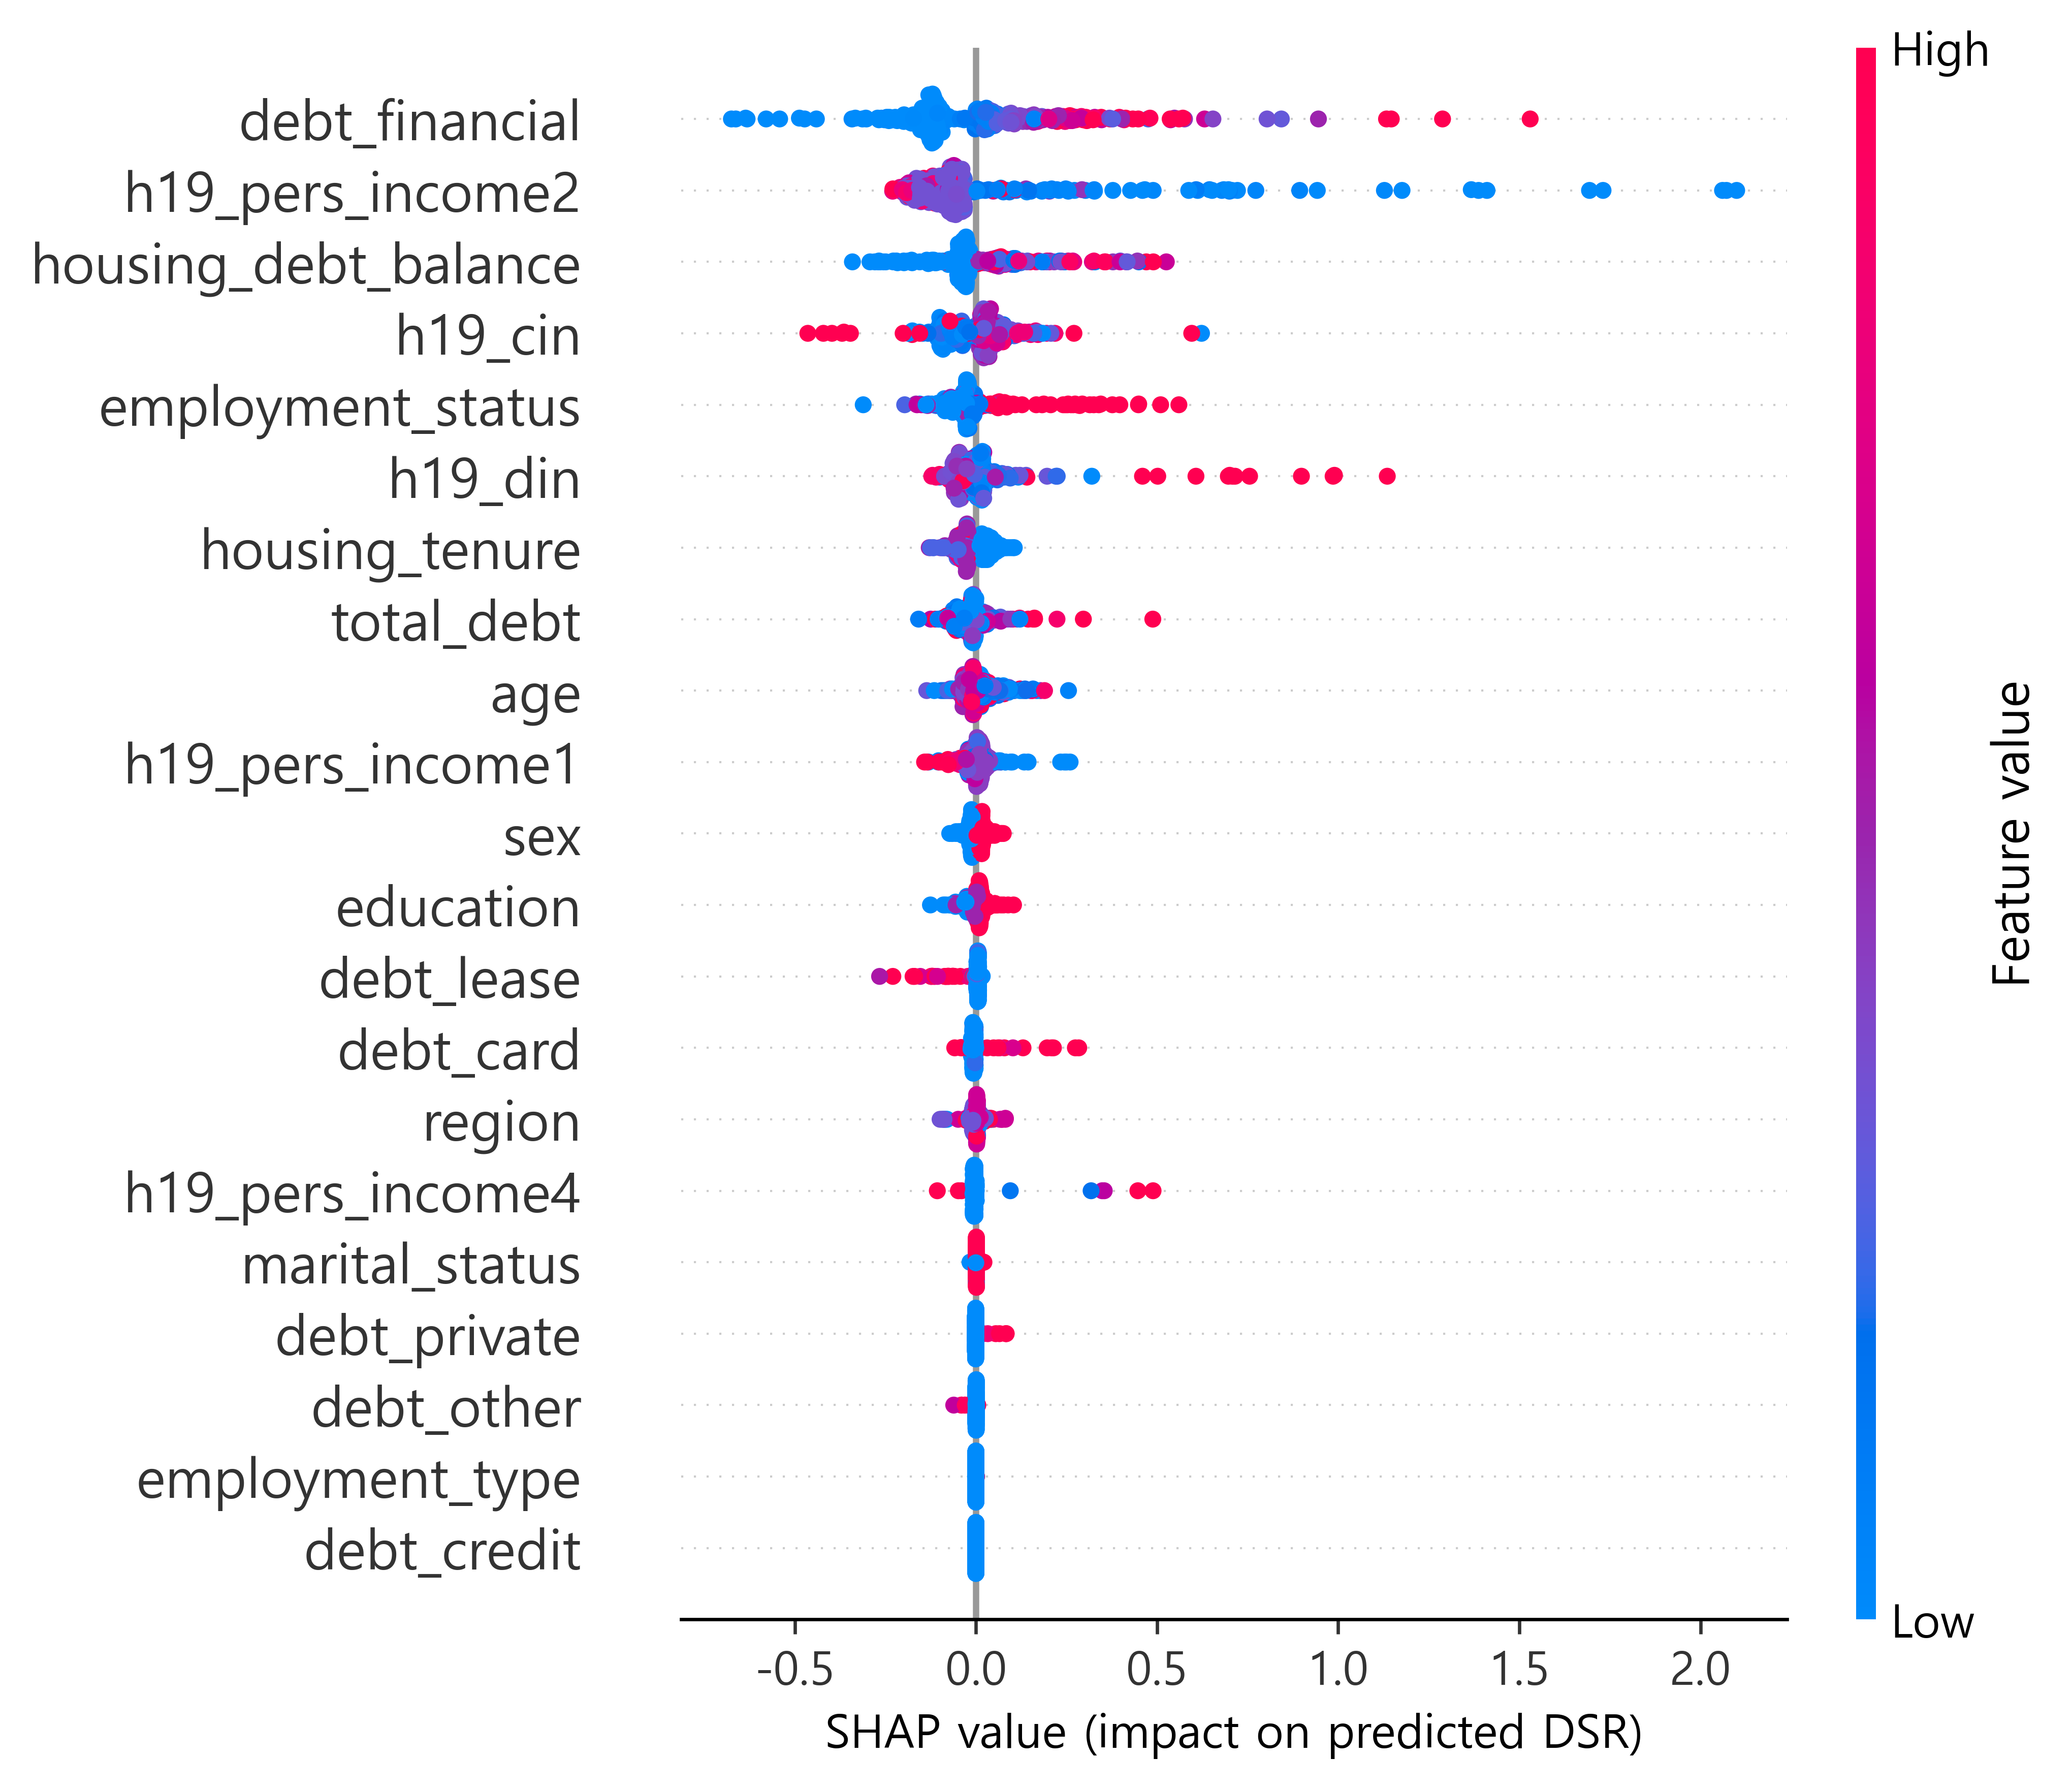

Saved -> outputs/10_shap_summary_reg.png


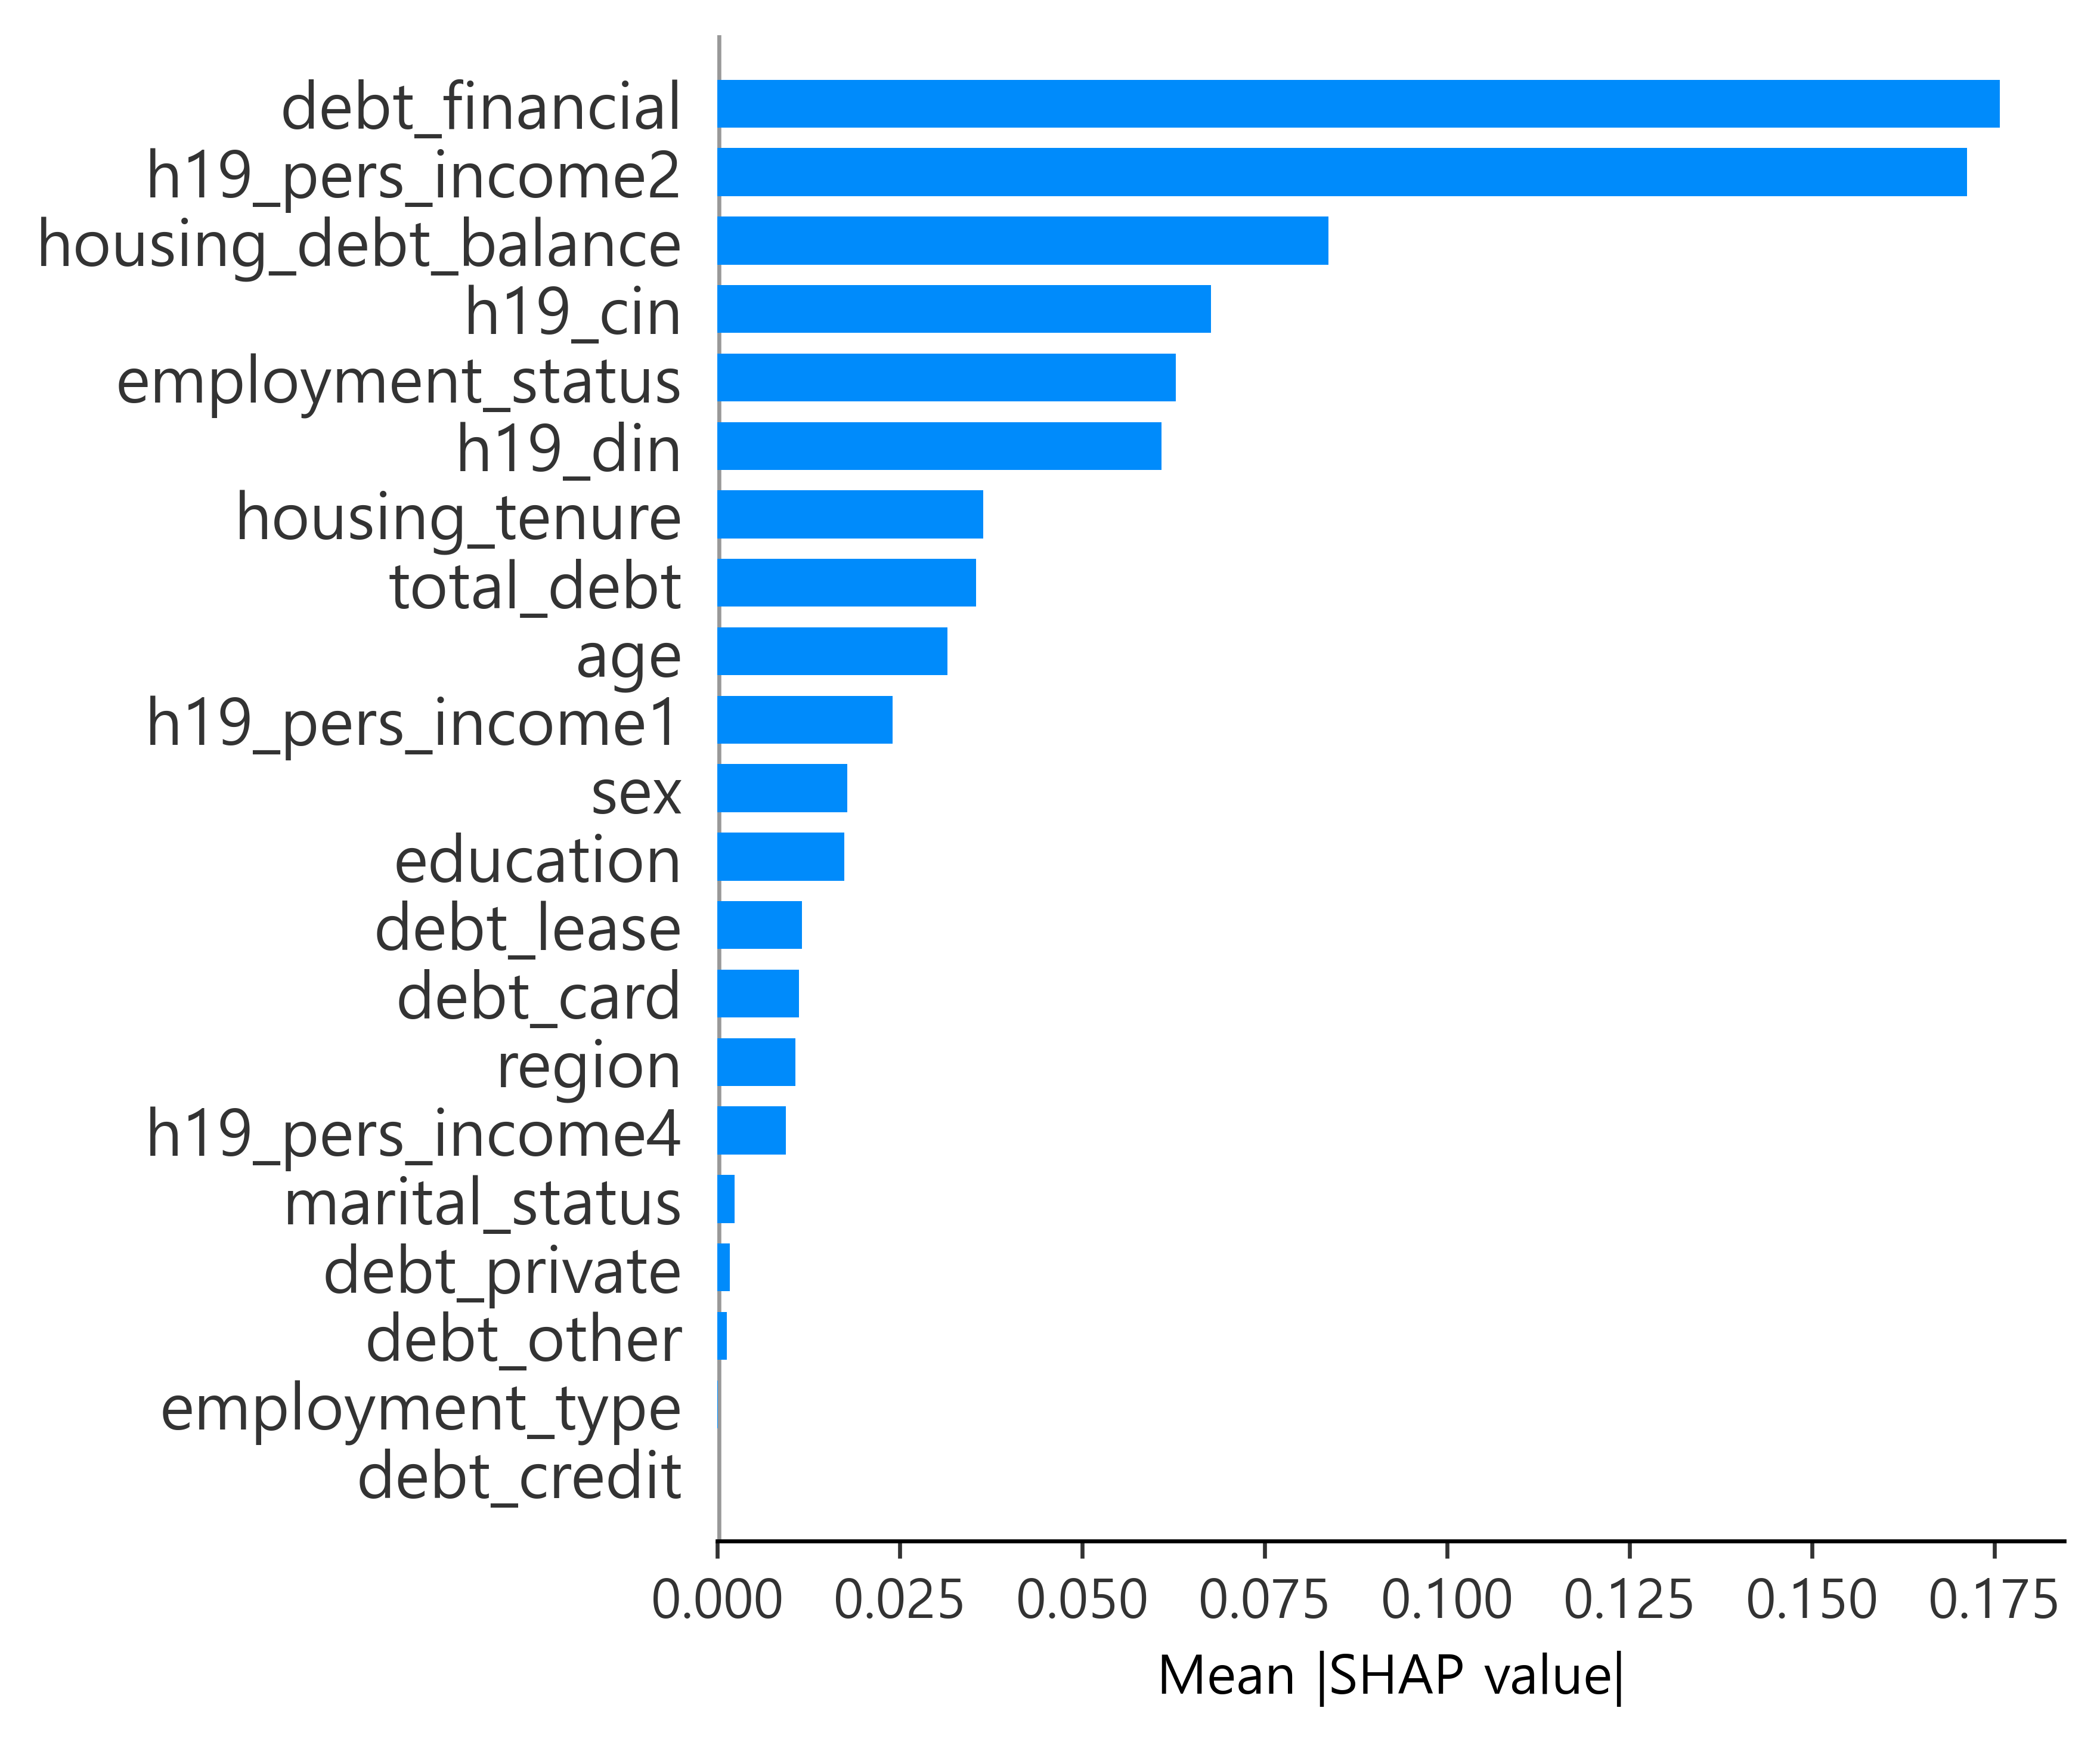

Saved -> outputs/11_shap_bar_reg.png
=== SHAP Feature Importance Ranking (Regression) ===
             feature  mean_abs_shap  rank
      debt_financial       0.175739     1
    h19_pers_income2       0.171214     2
housing_debt_balance       0.083719     3
             h19_cin       0.067645     4
   employment_status       0.062761     5
             h19_din       0.060851     6
      housing_tenure       0.036366     7
          total_debt       0.035457     8
                 age       0.031508     9
    h19_pers_income1       0.024020    10
                 sex       0.017808    11
           education       0.017380    12
          debt_lease       0.011532    13
           debt_card       0.011150    14
              region       0.010673    15
    h19_pers_income4       0.009377    16
      marital_status       0.002359    17
        debt_private       0.001695    18
          debt_other       0.001289    19
     employment_type       0.000059    20
         debt_credit       0

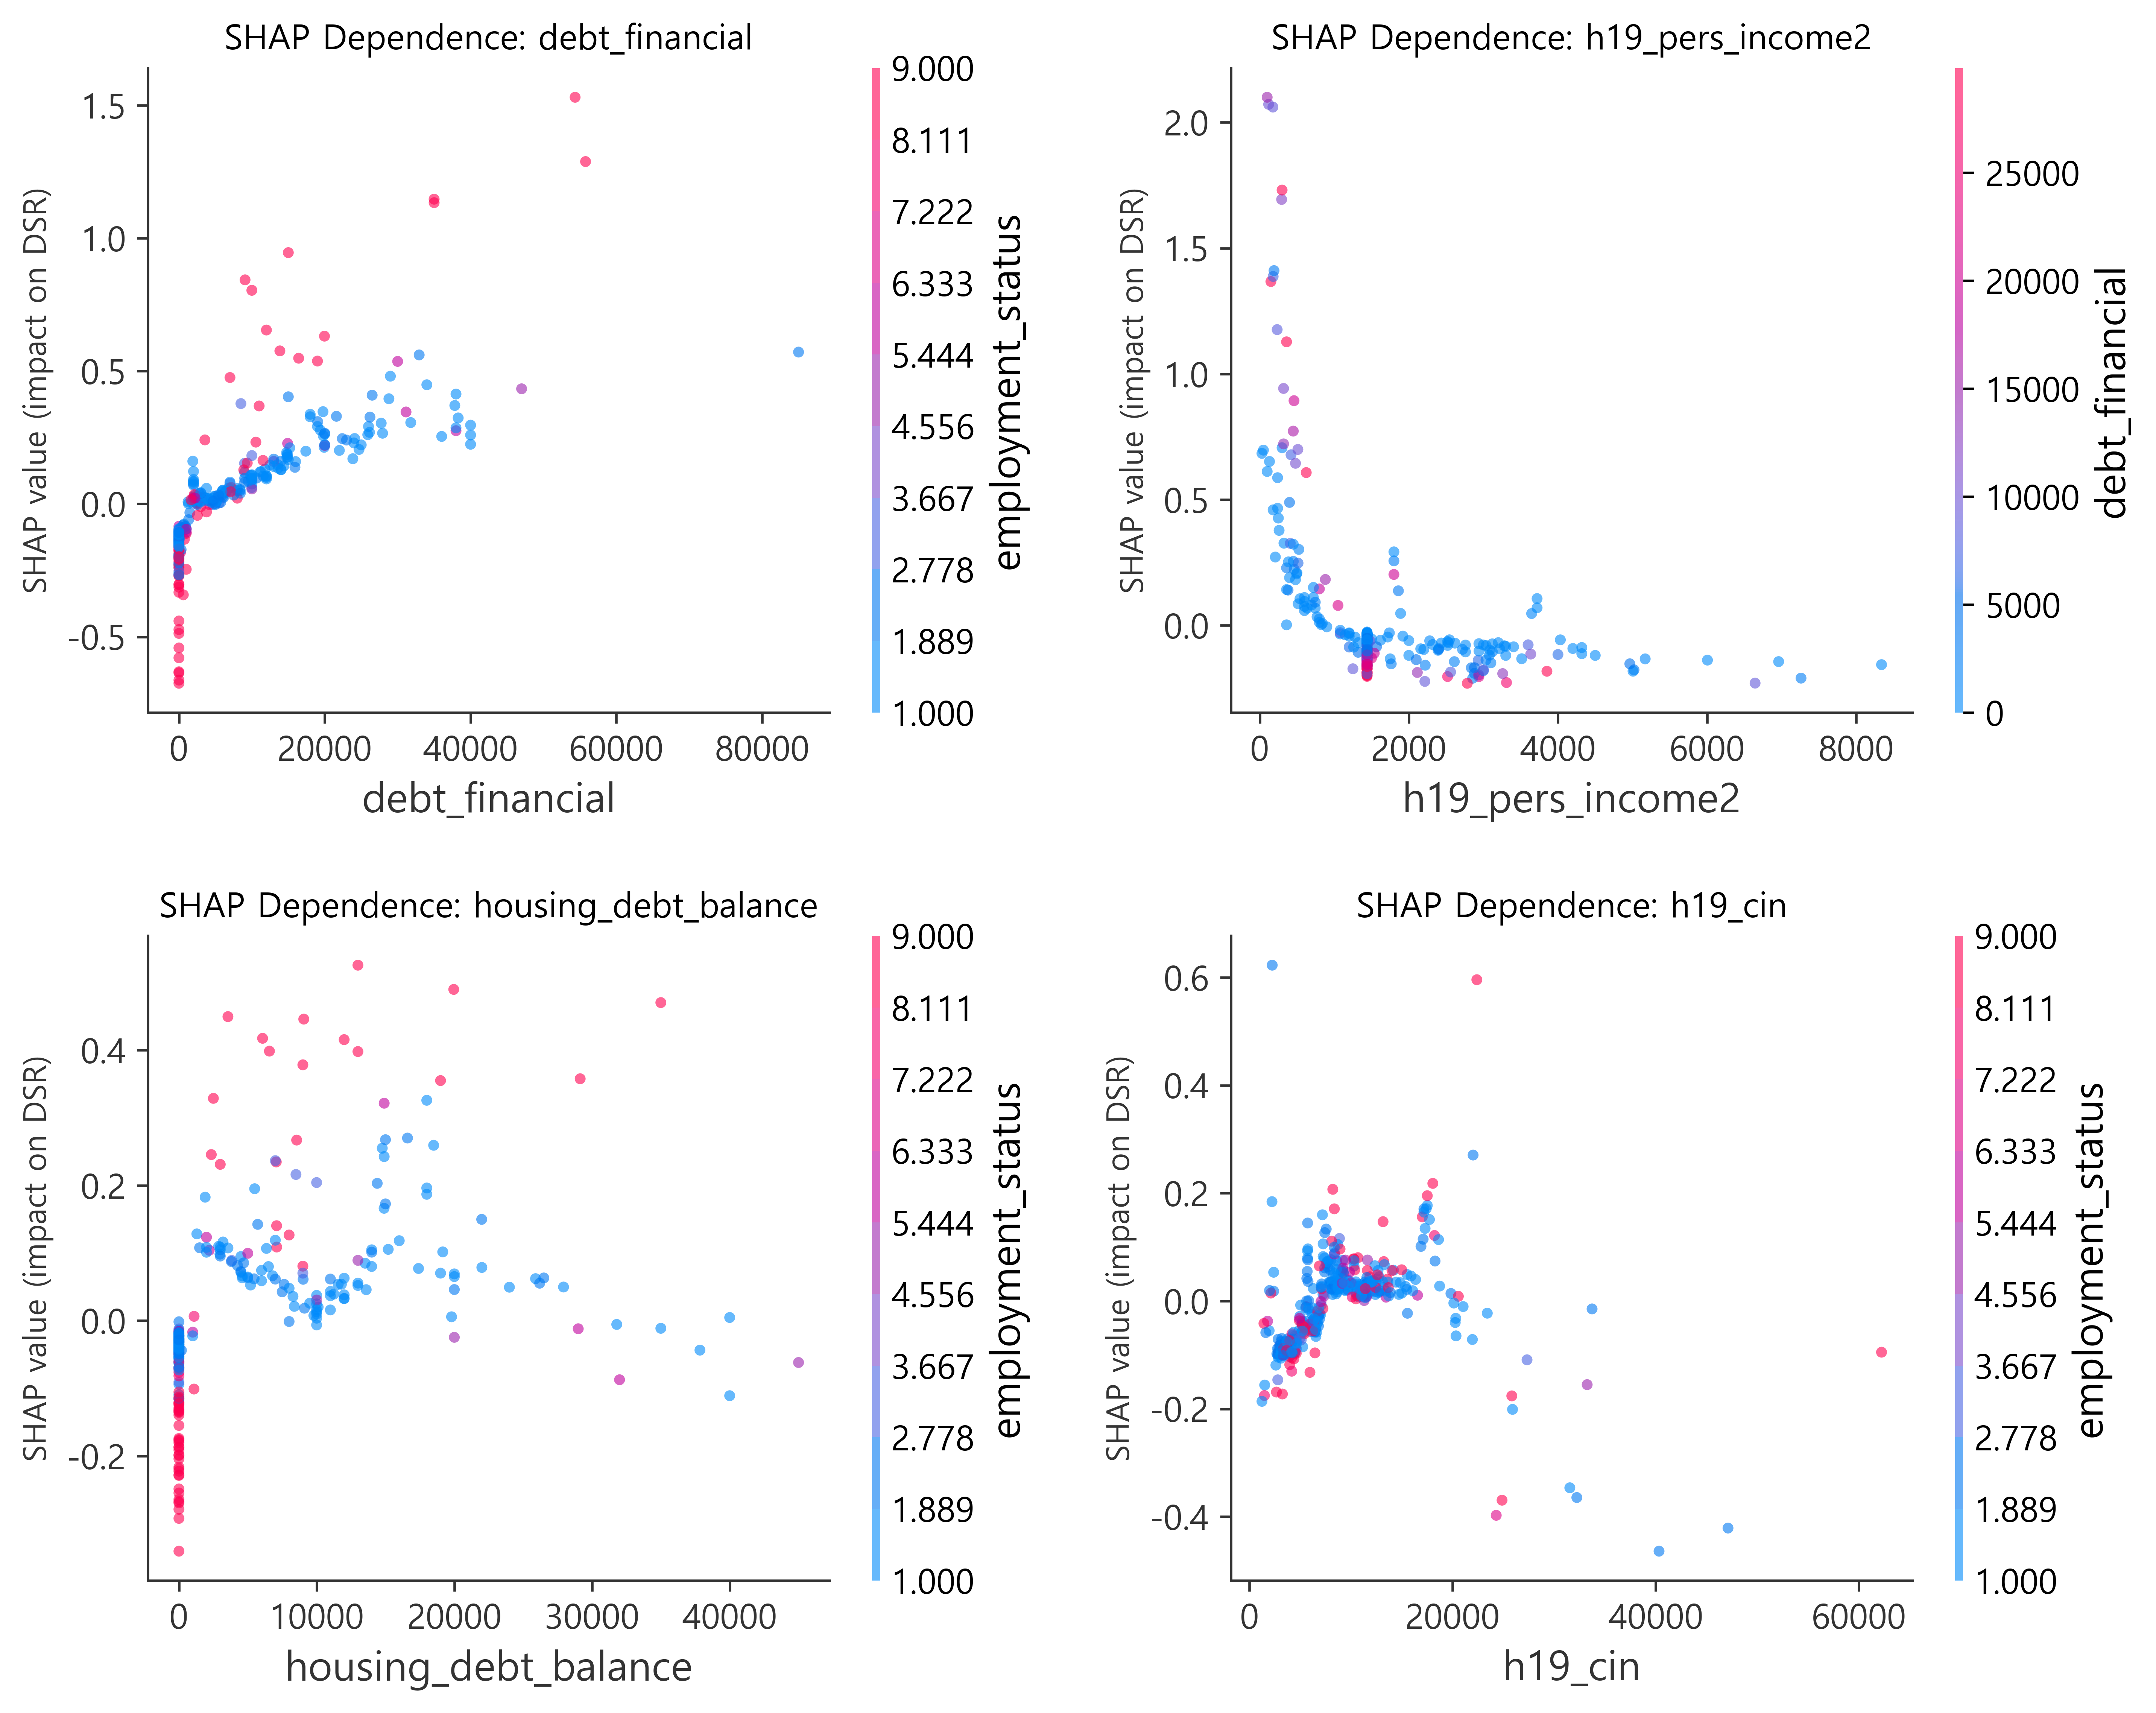

Saved -> outputs/12_shap_dependence_reg.png
Saved temp -> ../outputs/tmp_waterfall_0.png
Saved temp -> ../outputs/tmp_waterfall_1.png
Saved temp -> ../outputs/tmp_waterfall_2.png
Saved -> outputs/13_shap_waterfall_highdsr.png


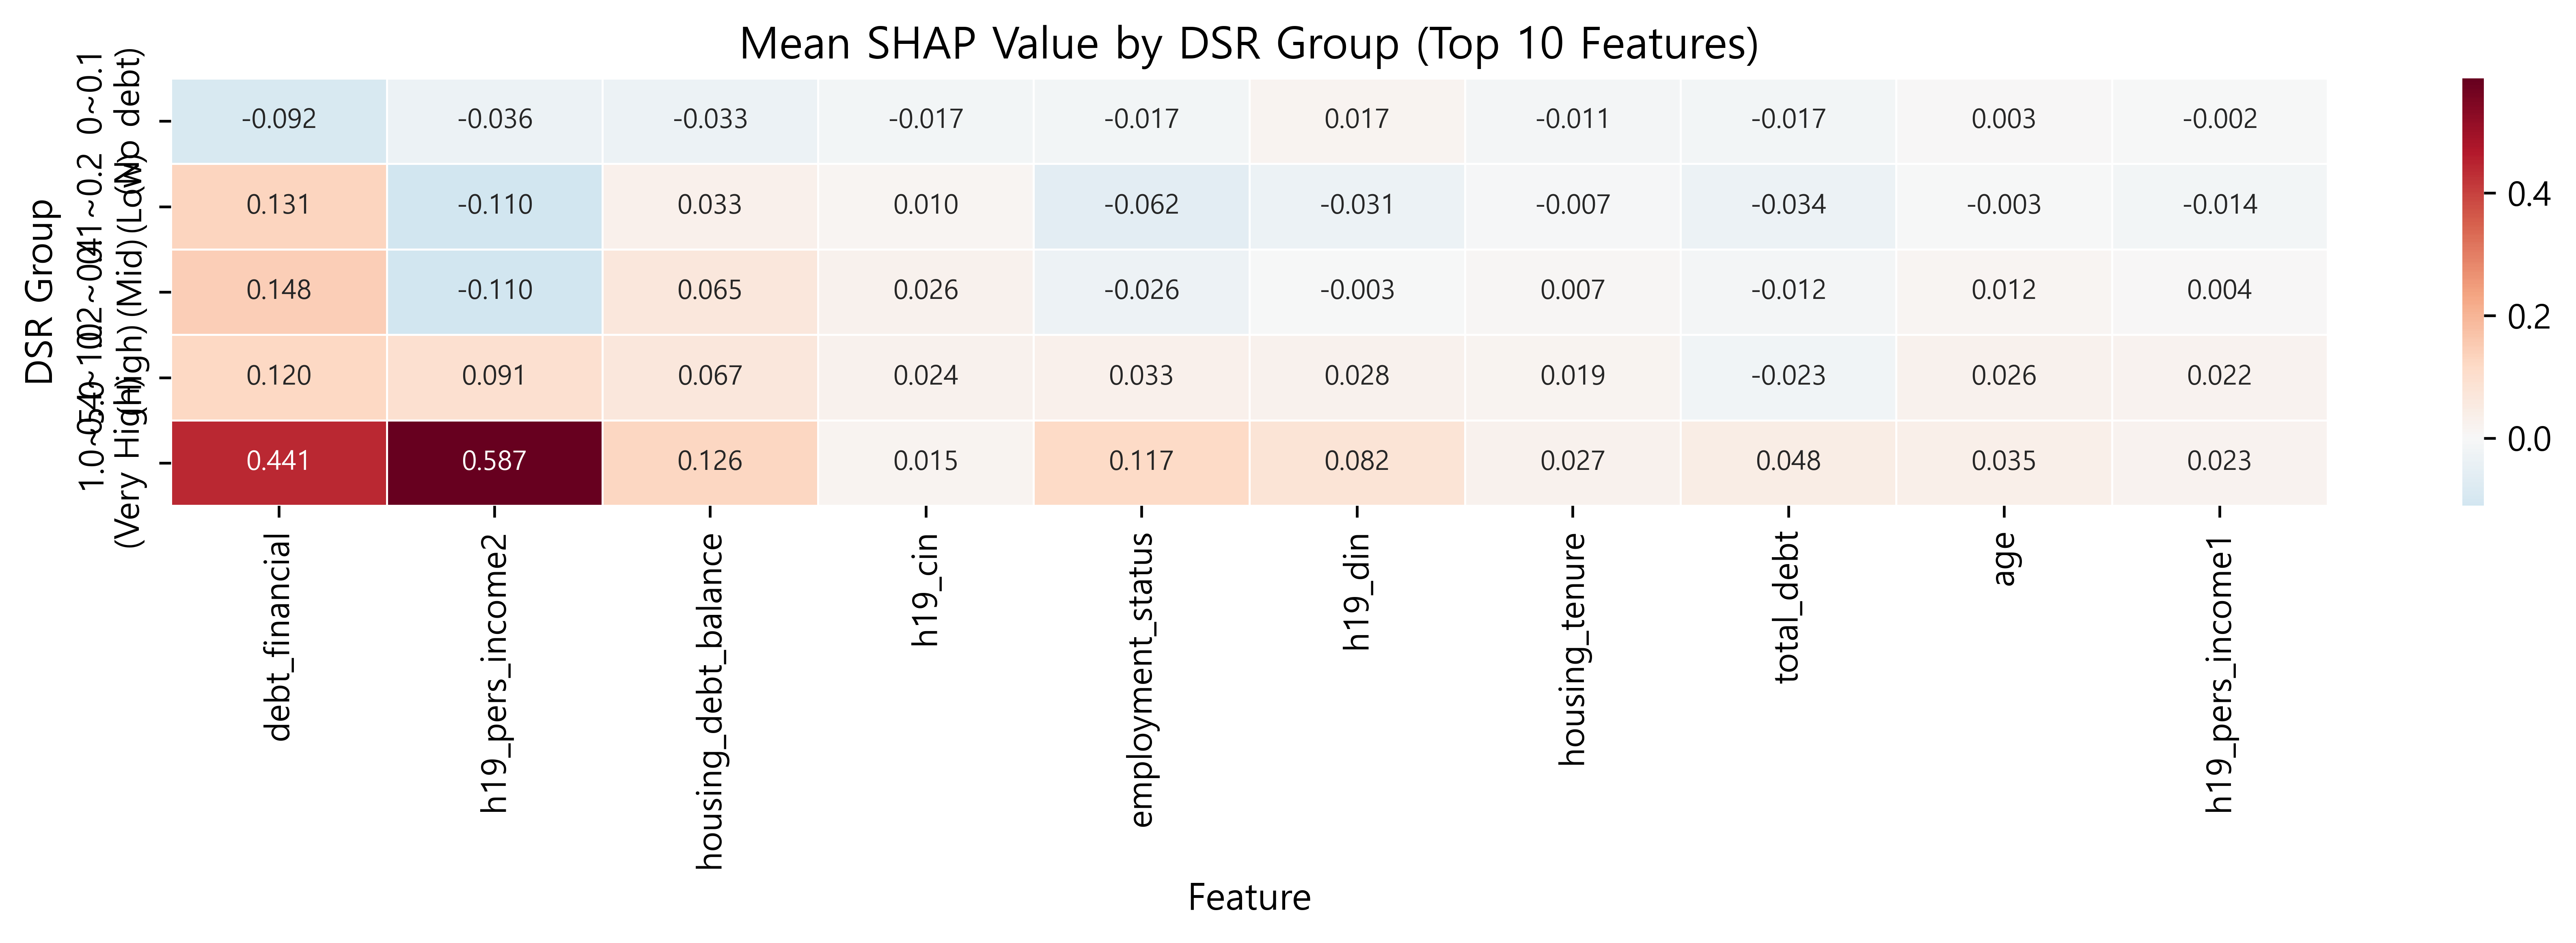

Saved -> outputs/14_shap_group_heatmap_reg.png


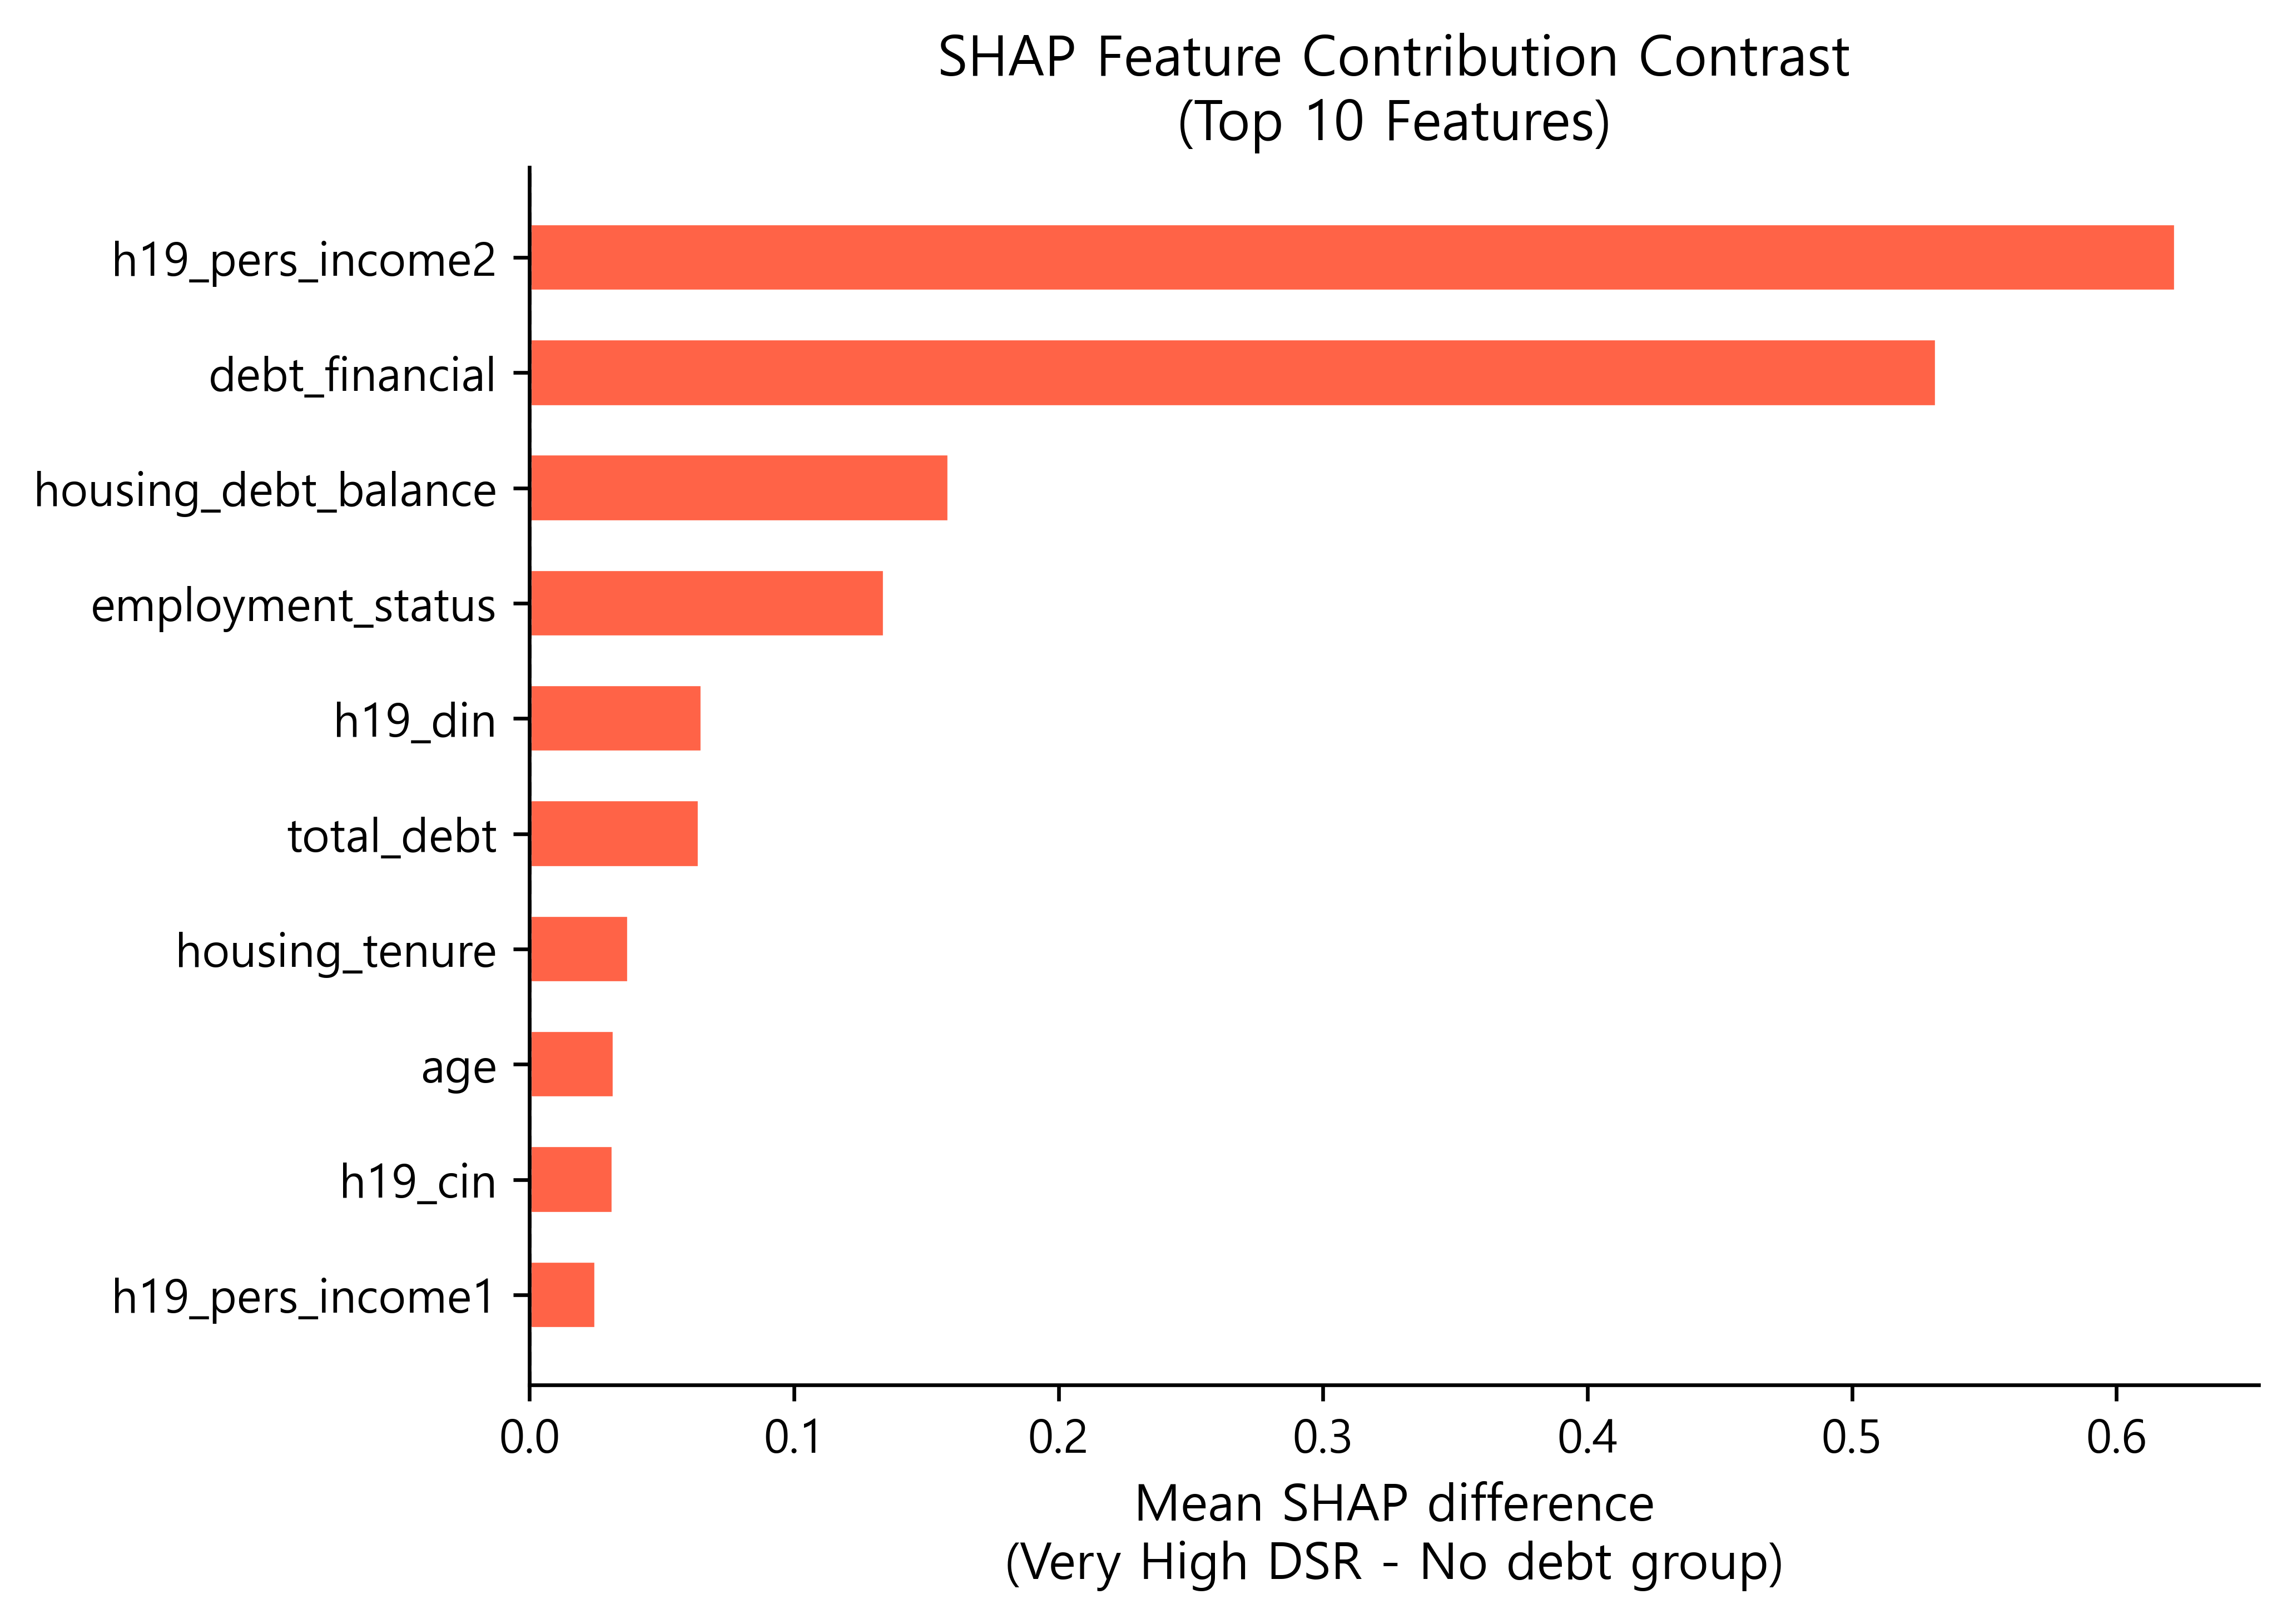

Saved -> outputs/15_shap_group_diff_reg.png


In [2]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import warnings
from PIL import Image
import os

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# Regression model and data loaded (_reg suffix)
# ─────────────────────────────────────────────
lgbm   = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test = pd.read_csv('../data/X_test_reg.csv')
y_test = pd.read_csv('../data/y_test_reg.csv').squeeze()
X_train = pd.read_csv('../data/X_train_reg.csv')

print(f"X_test shape  : {X_test.shape}")
print(f"X_train shape : {X_train.shape}")
print(f"y_test (DSR)  : mean={y_test.mean():.4f}, std={y_test.std():.4f}")


# ─────────────────────────────────────────────
# Cell 3 | Compute SHAP values
# Regression output: single SHAP array (no class dimension)
# expected_value is a scalar (mean predicted DSR)
# ─────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# For regression, shap_values is a 2D array (n_samples x n_features)
# No need to index by class as in classification
sv      = shap_values
exp_val = float(explainer.expected_value)

print(f"SHAP values shape : {sv.shape}")
print(f"Expected value (mean predicted DSR) : {exp_val:.4f}")


# ─────────────────────────────────────────────
# Cell 4 | Beeswarm summary plot
# Color = feature value (red=high, blue=low)
# X-axis = SHAP impact on predicted DSR
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
shap.summary_plot(sv, X_test, show=False, max_display=21, plot_size=None)
ax = plt.gca()
ax.set_xlabel('SHAP value (impact on predicted DSR)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/10_shap_summary_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/10_shap_summary_reg.png")


# ─────────────────────────────────────────────
# Cell 5 | Bar importance plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
shap.summary_plot(sv, X_test, plot_type='bar', show=False,
                  max_display=21, plot_size=None)
ax = plt.gca()
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/11_shap_bar_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/11_shap_bar_reg.png")


# ─────────────────────────────────────────────
# Cell 6 | SHAP importance table
# ─────────────────────────────────────────────
mean_shap = pd.DataFrame({
    'feature'       : X_test.columns,
    'mean_abs_shap' : np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap['rank'] = range(1, len(mean_shap) + 1)

print("=== SHAP Feature Importance Ranking (Regression) ===")
print(mean_shap.to_string(index=False))

mean_shap.to_csv('../outputs/shap_importance_reg.csv',
                 index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/shap_importance_reg.csv")


# ─────────────────────────────────────────────
# Cell 7 | Dependence plots (top 4 features)
# ─────────────────────────────────────────────
top4 = mean_shap['feature'].iloc[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, feat in enumerate(top4):
    shap.dependence_plot(feat, sv, X_test, ax=axes[i], show=False,
                         interaction_index='auto', dot_size=12, alpha=0.6)
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=11, pad=6)
    axes[i].set_ylabel('SHAP value (impact on DSR)', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/12_shap_dependence_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/12_shap_dependence_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | Waterfall plots — 3 high-DSR cases
# Select top-3 cases by actual DSR (highest debt burden)
# ─────────────────────────────────────────────
X_test_r = X_test.reset_index(drop=True)
y_test_r  = y_test.reset_index(drop=True)

# Select 3 cases with highest actual DSR for illustration
high_dsr_pos = y_test_r.nlargest(3).index.tolist()

tmp_paths = []
for i, pos in enumerate(high_dsr_pos):
    shap_obj = shap.Explanation(
        values        = sv[pos],
        base_values   = exp_val,
        data          = X_test_r.iloc[pos].values,
        feature_names = X_test.columns.tolist()
    )
    fig, ax = plt.subplots(figsize=(9, 7))
    plt.sca(ax)
    shap.plots.waterfall(shap_obj, max_display=10, show=False)
    ax.set_title(f'High-DSR Case #{i+1}  (Actual DSR={y_test_r.iloc[pos]:.3f})',
                 fontsize=12, pad=8)
    path = f'../outputs/tmp_waterfall_{i}.png'
    plt.savefig(path, dpi=600, bbox_inches='tight', format='png')
    plt.close()
    tmp_paths.append(path)
    print(f"Saved temp -> {path}")

# Combine three waterfall plots horizontally
imgs    = [Image.open(p) for p in tmp_paths]
total_w = sum(im.width for im in imgs)
max_h   = max(im.height for im in imgs)
combined = Image.new('RGB', (total_w, max_h), (255, 255, 255))
x_offset = 0
for im in imgs:
    combined.paste(im, (x_offset, 0))
    x_offset += im.width

combined.save('../outputs/13_shap_waterfall_highdsr.png', dpi=(600, 600))

# Remove temporary files
for p in tmp_paths:
    os.remove(p)

print("Saved -> outputs/13_shap_waterfall_highdsr.png")


# ─────────────────────────────────────────────
# Cell 9 | Mean SHAP by DSR group
# Group comparison by policy-based DSR intervals
# (replaces binary crisis/non-crisis comparison)
# ─────────────────────────────────────────────
shap_df = pd.DataFrame(sv, columns=X_test.columns)

# Assign DSR group to test set observations
dsr_bins   = [0, 0.1, 0.2, 0.4, 1.0, 5.01]
dsr_labels = ['0~0.1\n(No debt)', '0.1~0.2\n(Low)',
              '0.2~0.4\n(Mid)', '0.4~1.0\n(High)', '1.0~5.0\n(Very High)']
shap_df['dsr_group'] = pd.cut(y_test_r, bins=dsr_bins,
                               labels=dsr_labels, include_lowest=True)

# Mean SHAP per group for top-10 features
top10_feats  = mean_shap['feature'].iloc[:10].tolist()
group_shap   = shap_df.groupby('dsr_group', observed=True)[top10_feats].mean()

# Heatmap: rows = DSR groups, cols = top features
fig, ax = plt.subplots(figsize=(12, 4))
import seaborn as sns
sns.heatmap(group_shap, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Mean SHAP Value by DSR Group (Top 10 Features)', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('DSR Group', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/14_shap_group_heatmap_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/14_shap_group_heatmap_reg.png")


# ─────────────────────────────────────────────
# Cell 10 | SHAP difference bar: Very High vs No-debt
# Highlights which features most distinguish
# extreme DSR groups (policy-relevant contrast)
# ─────────────────────────────────────────────
if ('1.0~5.0\n(Very High)' in group_shap.index and
        '0~0.1\n(No debt)' in group_shap.index):

    diff = (group_shap.loc['1.0~5.0\n(Very High)'] -
            group_shap.loc['0~0.1\n(No debt)'])
    diff = diff.sort_values(ascending=True)
    colors = ['tomato' if v > 0 else 'steelblue' for v in diff]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(diff.index, diff.values,
            color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel('Mean SHAP difference\n(Very High DSR - No debt group)',
                  fontsize=11)
    ax.set_title('SHAP Feature Contribution Contrast\n(Top 10 Features)',
                 fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/15_shap_group_diff_reg.png', **SAVE_KW)
    plt.show()
    print("Saved -> outputs/15_shap_group_diff_reg.png")
else:
    print("Skipped: one or both DSR groups absent in test set.")